In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("olist_order_reviews_dataset_cle.csv")
df.head(10)

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,No Title,No review comment,18-01-2018 00:00,18-01-2018 21:46
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,No Title,No review comment,10-03-2018 00:00,11-03-2018 03:05
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,No Title,No review comment,17-02-2018 00:00,18-02-2018 14:36
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,No Title,Recebi bem antes do prazo estipulado.,21-04-2017 00:00,21-04-2017 22:02
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,No Title,Parabéns lojas lannister adorei comprar pela I...,01-03-2018 00:00,02-03-2018 10:26
5,15197aa66ff4d0650b5434f1b46cda19,b18dcdf73be66366873cd26c5724d1dc,1,No Title,No review comment,13-04-2018 00:00,16-04-2018 00:39
6,07f9bee5d1b850860defd761afa7ff16,e48aa0d2dcec3a2e87348811bcfdf22b,5,No Title,No review comment,16-07-2017 00:00,18-07-2017 19:30
7,7c6400515c67679fbee952a7525281ef,c31a859e34e3adac22f376954e19b39d,5,No Title,No review comment,14-08-2018 00:00,14-08-2018 21:36
8,a3f6f7f6f433de0aefbb97da197c554c,9c214ac970e84273583ab523dfafd09b,5,No Title,No review comment,17-05-2017 00:00,18-05-2017 12:05
9,8670d52e15e00043ae7de4c01cc2fe06,b9bf720beb4ab3728760088589c62129,4,recomendo,aparelho eficiente. no site a marca do aparelh...,22-05-2018 00:00,23-05-2018 16:45


In [61]:
df.isnull().sum()

review_id                        0
order_id                         0
review_score                     0
review_comment_title             0
review_comment_message           0
review_creation_date             0
review_answer_timestamp          0
review_month                     0
review_year                      0
review_day                       0
review_response_time_in_days     0
review_response_time_in_hours    0
comment_length                   0
comment_word_count               0
dtype: int64

In [4]:
df.columns

Index(['review_id', 'order_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp'],
      dtype='object')

In [5]:
df.isnull().sum()

review_id                  0
order_id                   0
review_score               0
review_comment_title       0
review_comment_message     0
review_creation_date       0
review_answer_timestamp    0
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     99224 non-null  object
 4   review_comment_message   99224 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


In [7]:
date_columns = [
    "review_creation_date",
    "review_answer_timestamp"
]

for col in date_columns:
    df[col] = pd.to_datetime(
        df[col],
        format = "%d-%m-%Y %H:%M",
        errors="coerce"
    )

Text(0, 0.5, 'Number of Reviews')

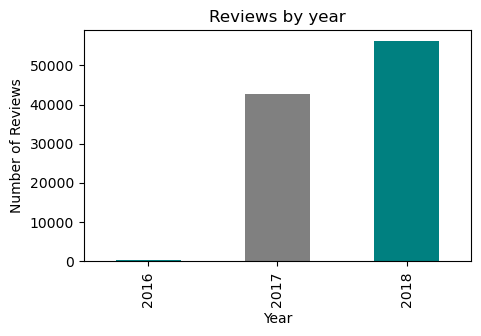

In [8]:
ax = df["review_creation_date"].dt.year.value_counts().sort_index().plot(
    kind = "bar",
    figsize = (5,3),
    color = ["teal","grey"],
    title = "Reviews by year"
)
ax.set_xlabel("Year")
ax.set_ylabel("Number of Reviews")

2018 got 5614 reviews ,2017 42735 and 2016 only 325

In [9]:
df["review_creation_date"].dt.year.value_counts()

review_creation_date
2018    56164
2017    42735
2016      325
Name: count, dtype: int64

Text(0, 0.5, 'Number of Reviews')

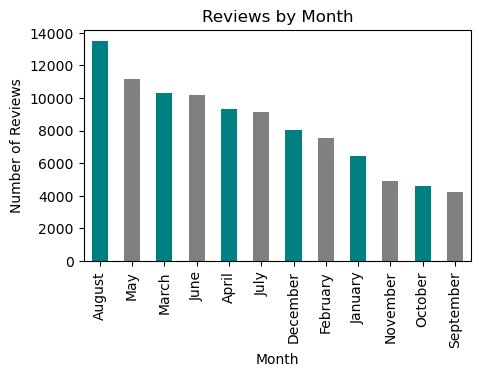

In [15]:
ax = df["review_month"].value_counts().sort_values(ascending=False).plot(
    kind = "bar",
    figsize = (5,3),
    color = ["teal","grey"],
    title = "Reviews by Month"
)
ax.set_xlabel("Month")
ax.set_ylabel("Number of Reviews")

In [13]:
df["review_month"] = df["review_creation_date"].dt.month_name()
df["review_year"] = df["review_creation_date"].dt.year
df["review_day"] = df["review_creation_date"].dt.day_name()
df["review_month"] = df["review_creation_date"].dt.month_name()
df["review_year"] = df["review_creation_date"].dt.year


In [14]:
df.head(10)

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,review_month,review_year,review_day
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,No Title,No review comment,2018-01-18,2018-01-18 21:46:00,January,2018,Thursday
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,No Title,No review comment,2018-03-10,2018-03-11 03:05:00,March,2018,Saturday
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,No Title,No review comment,2018-02-17,2018-02-18 14:36:00,February,2018,Saturday
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,No Title,Recebi bem antes do prazo estipulado.,2017-04-21,2017-04-21 22:02:00,April,2017,Friday
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,No Title,Parabéns lojas lannister adorei comprar pela I...,2018-03-01,2018-03-02 10:26:00,March,2018,Thursday
5,15197aa66ff4d0650b5434f1b46cda19,b18dcdf73be66366873cd26c5724d1dc,1,No Title,No review comment,2018-04-13,2018-04-16 00:39:00,April,2018,Friday
6,07f9bee5d1b850860defd761afa7ff16,e48aa0d2dcec3a2e87348811bcfdf22b,5,No Title,No review comment,2017-07-16,2017-07-18 19:30:00,July,2017,Sunday
7,7c6400515c67679fbee952a7525281ef,c31a859e34e3adac22f376954e19b39d,5,No Title,No review comment,2018-08-14,2018-08-14 21:36:00,August,2018,Tuesday
8,a3f6f7f6f433de0aefbb97da197c554c,9c214ac970e84273583ab523dfafd09b,5,No Title,No review comment,2017-05-17,2017-05-18 12:05:00,May,2017,Wednesday
9,8670d52e15e00043ae7de4c01cc2fe06,b9bf720beb4ab3728760088589c62129,4,recomendo,aparelho eficiente. no site a marca do aparelh...,2018-05-22,2018-05-23 16:45:00,May,2018,Tuesday


In [16]:
df["review_response_time_in_days"] = (
df["review_answer_timestamp"]-
df["review_creation_date"]).dt.days

In [31]:
df["review_response_time_in_hours"] = (
    df["review_answer_timestamp"] -
    df["review_creation_date"]
).dt.total_seconds() / 3600

In [17]:
df["review_response_time_in_days"].mean()

2.582248246392002

In [18]:
df["review_response_time_in_days"].max()

518

In [32]:
df = df.rename(columns={"review_answered_time_in_hrs":"review_response_time_in_hrs"})

In [33]:
(df["review_comment_title"].value_counts(normalize=True) * 100).round(2).head(10)

review_comment_title
No Title           88.34
Recomendo           0.43
recomendo           0.35
Bom                 0.30
super recomendo     0.27
Excelente           0.25
Muito bom           0.25
Ótimo               0.24
Super recomendo     0.22
Ótimo               0.21
Name: proportion, dtype: float64

In [22]:
(df["review_comment_message"].value_counts(normalize=True) * 100).round(2).head(10)

review_comment_message
No review comment    58.70
Muito bom             0.23
Bom                   0.19
muito bom             0.12
bom                   0.11
Recomendo             0.10
Otimo                 0.10
otimo                 0.10
Ótimo                 0.08
Ótimo                 0.07
Name: proportion, dtype: float64

58.70% of customers didn't wrote any review comment message 

In [23]:
df["review_score"].mean()

4.08642062404257

4 is the average review score

Text(0.5, 0, 'Ratings')

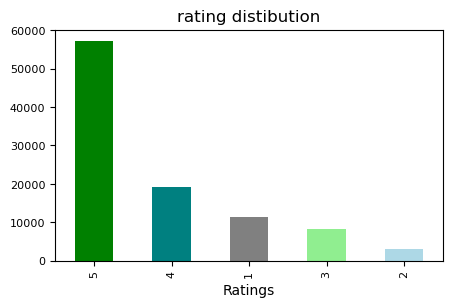

In [24]:
ratings = df["review_score"].value_counts().plot(
    kind = "bar",
    title = "rating distibution",
    figsize= (5,3),
    color = ["green","teal","grey","lightgreen","lightblue"],
    fontsize=8
)
ratings.set_xlabel("Ratings")

In [38]:
#df["review_response_time_in_hrs"].value_counts()
df.head(10)

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,review_month,review_year,review_day,review_response_time_in_days,review_response_time_in_hours,comment_length
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,No Title,No review comment,2018-01-18,2018-01-18 21:46:00,January,2018,Thursday,0,21.766667,17
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,No Title,No review comment,2018-03-10,2018-03-11 03:05:00,March,2018,Saturday,1,27.083333,17
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,No Title,No review comment,2018-02-17,2018-02-18 14:36:00,February,2018,Saturday,1,38.600000,17
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,No Title,Recebi bem antes do prazo estipulado.,2017-04-21,2017-04-21 22:02:00,April,2017,Friday,0,22.033333,37
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,No Title,Parabéns lojas lannister adorei comprar pela I...,2018-03-01,2018-03-02 10:26:00,March,2018,Thursday,1,34.433333,100
5,15197aa66ff4d0650b5434f1b46cda19,b18dcdf73be66366873cd26c5724d1dc,1,No Title,No review comment,2018-04-13,2018-04-16 00:39:00,April,2018,Friday,3,72.650000,17
6,07f9bee5d1b850860defd761afa7ff16,e48aa0d2dcec3a2e87348811bcfdf22b,5,No Title,No review comment,2017-07-16,2017-07-18 19:30:00,July,2017,Sunday,2,67.500000,17
7,7c6400515c67679fbee952a7525281ef,c31a859e34e3adac22f376954e19b39d,5,No Title,No review comment,2018-08-14,2018-08-14 21:36:00,August,2018,Tuesday,0,21.600000,17
8,a3f6f7f6f433de0aefbb97da197c554c,9c214ac970e84273583ab523dfafd09b,5,No Title,No review comment,2017-05-17,2017-05-18 12:05:00,May,2017,Wednesday,1,36.083333,17
9,8670d52e15e00043ae7de4c01cc2fe06,b9bf720beb4ab3728760088589c62129,4,recomendo,aparelho eficiente. no site a marca do aparelh...,2018-05-22,2018-05-23 16:45:00,May,2018,Tuesday,1,40.750000,174


Text(0, 0.5, '')

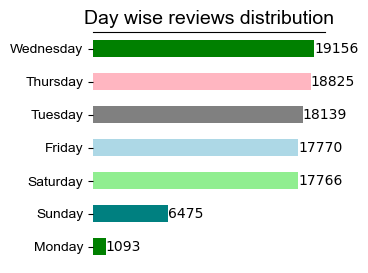

In [35]:
ax = df["review_day"].value_counts().sort_values().plot(
    kind = "barh",
    title = "Day wise reviews distribution",
    figsize = (3,3),
    color = ["green","teal","lightgreen","lightblue","grey","lightpink"]
   

)
for container in ax.containers:
    ax.bar_label(container)
ax.spines["left"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.set_xticks([])  
plt.xticks(fontfamily="Arial")
plt.yticks(fontfamily="Arial")
ax.set_title(
    "Day wise reviews distribution",
    fontsize=14,
    fontfamily="Arial"
)
# ax.set_xlabel(
#     "Order Status",
#     fontfamily="Arial",
#     fontsize=12
# )

# ax.set_ylabel(
#     fontfamily="Arial",
#     fontsize=12
# )
plt.ylabel("")

In [37]:
df["comment_length"] = df["review_comment_message"].str.len()

In [39]:
df["comment_length"].max()

208

In [40]:
df["comment_length"].min()

1

In [43]:
df["comment_length"].mean()

38.32457873095219

In [44]:
df[["review_comment_message", "comment_length"]].head()

,review_comment_message,comment_length
0,No review comment,17
1,No review comment,17
2,No review comment,17
3,Recebi bem antes do prazo estipulado.,37
4,Parabéns lojas lannister adorei comprar pela I...,100


In [ ]:
df["comment_word_count"] = df["review_comment_message"].str.split().str.len()

In [48]:
df.head(5)

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,review_month,review_year,review_day,review_response_time_in_days,review_response_time_in_hours,comment_length,comment_word_count
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,No Title,No review comment,2018-01-18,2018-01-18 21:46:00,January,2018,Thursday,0,21.766667,17,3
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,No Title,No review comment,2018-03-10,2018-03-11 03:05:00,March,2018,Saturday,1,27.083333,17,3
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,No Title,No review comment,2018-02-17,2018-02-18 14:36:00,February,2018,Saturday,1,38.600000,17,3
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,No Title,Recebi bem antes do prazo estipulado.,2017-04-21,2017-04-21 22:02:00,April,2017,Friday,0,22.033333,37,6
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,No Title,Parabéns lojas lannister adorei comprar pela I...,2018-03-01,2018-03-02 10:26:00,March,2018,Thursday,1,34.433333,100,15


In [51]:
df.groupby("review_score").agg(
    average_comment_length=("comment_length", "mean")
)

,average_comment_length
review_score,
1,80.491422
2,71.353856
3,45.847292
4,30.964894
5,29.490528


Customers giving lower ratings tend to write longer comments, likely because they explain the issues they faced.

In [54]:
df[["review_score", "comment_length"]].corr()

,review_score,comment_length
review_score,1.000000,-0.386864
comment_length,-0.386864,1.000000


<Axes: title={'center': 'Average Comment Length by Review Score'}, xlabel='review_score'>

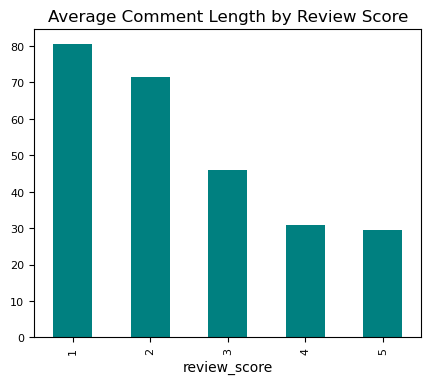

In [60]:
df.groupby("review_score")["comment_length"].mean().plot(
    kind="bar",
    color="teal",
    title="Average Comment Length by Review Score",
    figsize=(5,4),
    fontsize=8
)